# Feature Engineering — Cyclical Time Encoding

**Purpose:** Encode hour of day, day of week, and month of year as cyclical features.

**How to use:** Copy `compute_time_features()` into your `feature_pipeline()` — add it after your existing indicator functions.

---

| Feature | Cycle | Signal |
|---|---|---|
| `hour_sin` / `hour_cos` | 24h | Intraday session patterns (Asia / Europe / US) |
| `dow_sin` / `dow_cos` | 7 days | Weekend vs. weekday volume differences |
| `month_sin` / `month_cos` | 12 months | Seasonal BTC patterns (weaker — only 8 years of data) |

## 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2 — Load Data

In [2]:
df = pd.read_csv('btc_1hour_cleaned.csv')
df['Open time'] = pd.to_datetime(df['Open time'])
df = df.set_index('Open time')

print(f"Dataset shape: {df.shape}")
df.head(2)

Dataset shape: (71588, 11)


,Open,High,Low,Close,Volume,Close time,Quote asset volume,Number of trades,Taker buy base asset volume,Taker buy quote asset volume,Ignore
Open time,,,,,,,,,,,
2018-01-01 00:00:00,13715.65,13715.65,13400.01,13529.01,443.356199,2018-01-01 00:59:59.999,5.993910e+06,5228,228.521921,3.090541e+06,0
2018-01-01 01:00:00,13528.99,13595.89,13155.38,13203.06,383.697006,2018-01-01 01:59:59.999,5.154522e+06,4534,180.840403,2.430449e+06,0


## 3 — Function: `compute_time_features()`

**Copy this function into your `feature_pipeline()`.**

No data leakage risk — this is pure mathematics, no `.fit()` needed.

```python
# How to add to your feature_pipeline():

def feature_pipeline(df):
    steps = [
        compute_roc,
        compute_macd,
        compute_adx,
        compute_atr,
        compute_natr,
        compute_time_features,   # ← add here
        compute_regime,
    ]
    for step in steps:
        df = step(df)
    return df
```

**Add to `feature_cols` in your feature matrix:**

```python
feature_cols = [
    'Volume', 'roc_10', 'roc_21', 'macd_histogram', 'adx',
    'hour_sin', 'hour_cos',
    'dow_sin',  'dow_cos',
    'month_sin', 'month_cos',
]
```

In [3]:
def compute_time_features(df):
    # Hour of day (0-23) — intraday session patterns
    # Asia: 02:00-08:00 UTC | Europe: 08:00-16:00 UTC | US: 13:00-21:00 UTC
    df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)

    # Day of week (0=Monday, 6=Sunday) — weekend vs weekday patterns
    df['dow_sin'] = np.sin(2 * np.pi * df.index.dayofweek / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df.index.dayofweek / 7)

    # Month of year (1-12) — seasonal BTC patterns
    df['month_sin'] = np.sin(2 * np.pi * df.index.month / 12)
    df['month_cos'] = np.cos(2 * np.pi * df.index.month / 12)

    return df


df = compute_time_features(df)

## 4 — Summary

In [4]:
feature_cols = ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']

print(f"New columns: {feature_cols}\n")
print(df[feature_cols].describe().round(4))
print(f"\nNull counts:\n{df[feature_cols].isnull().sum()}")
print(f"\nValue ranges (all must be between -1 and +1):")
for col in feature_cols:
    print(f"  {col}: min={df[col].min():.3f}  max={df[col].max():.3f}")

New columns: ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']

         hour_sin    hour_cos     dow_sin     dow_cos   month_sin   month_cos
count  71588.0000  71588.0000  71588.0000  71588.0000  71588.0000  71588.0000
mean      -0.0008     -0.0002     -0.0004      0.0003      0.0105      0.0117
std        0.7070      0.7072      0.7071      0.7071      0.7063      0.7077
min       -1.0000     -1.0000     -0.9749     -0.9010     -1.0000     -1.0000
25%       -0.7071     -0.7071     -0.7818     -0.9010     -0.5000     -0.5000
50%        0.0000     -0.0000      0.0000     -0.2225      0.0000      0.0000
75%        0.7071      0.7071      0.7818      0.6235      0.8660      0.8660
max        1.0000      1.0000      0.9749      1.0000      1.0000      1.0000

Null counts:
hour_sin     0
hour_cos     0
dow_sin      0
dow_cos      0
month_sin    0
month_cos    0
dtype: int64

Value ranges (all must be between -1 and +1):
  hour_sin: min=-1.000  max=1.000
  hour_cos: m

## 5 — Visualisation

These plots explain why sin/cos works better than a raw hour number.

**Key insight:** With raw numbers, hour 23 and hour 0 are 23 units apart. With sin/cos they are neighbours — exactly as they are in reality.

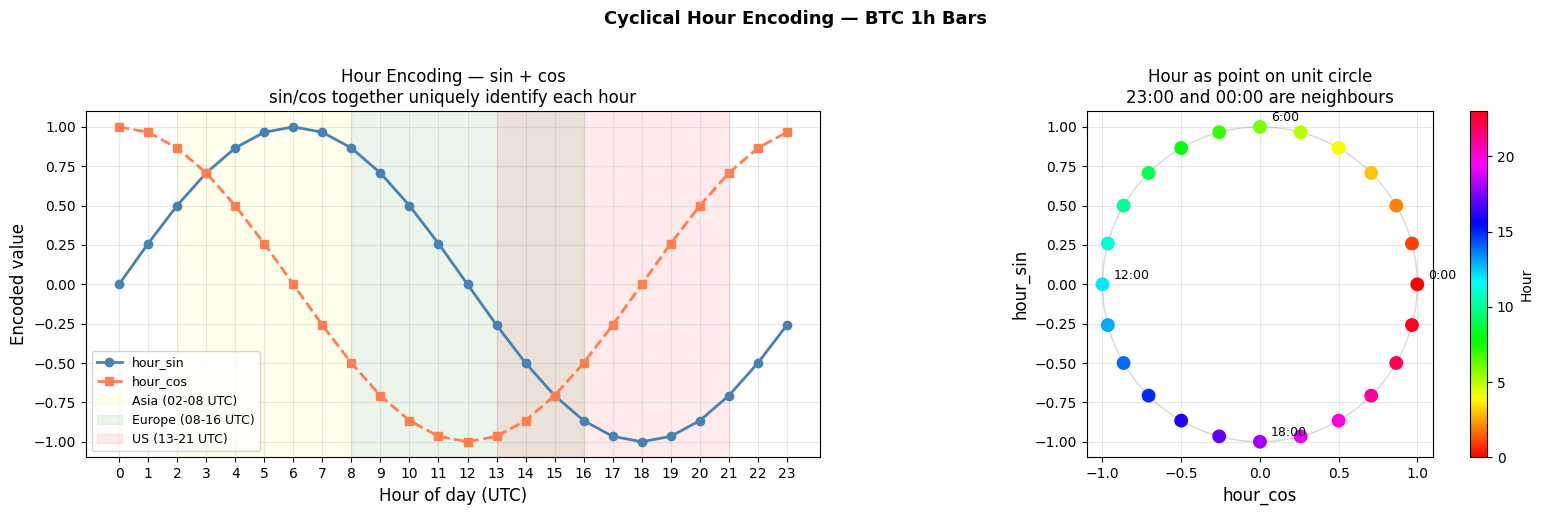

In [5]:
# ── Plot 1: Hour Encoding ──────────────────────────────────────────────────

hours = np.arange(24)
h_sin = np.sin(2 * np.pi * hours / 24)
h_cos = np.cos(2 * np.pi * hours / 24)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: sin and cos as lines
ax1 = axes[0]
ax1.plot(hours, h_sin, 'o-', color='steelblue', linewidth=2,
         markersize=6, label='hour_sin')
ax1.plot(hours, h_cos, 's--', color='coral', linewidth=2,
         markersize=6, label='hour_cos')
ax1.axvspan(2,  8,  alpha=0.08, color='yellow', label='Asia (02-08 UTC)')
ax1.axvspan(8,  16, alpha=0.08, color='green',  label='Europe (08-16 UTC)')
ax1.axvspan(13, 21, alpha=0.08, color='red',    label='US (13-21 UTC)')
ax1.set_xlabel('Hour of day (UTC)', fontsize=12)
ax1.set_ylabel('Encoded value', fontsize=12)
ax1.set_title('Hour Encoding — sin + cos\nsin/cos together uniquely identify each hour',
              fontsize=12)
ax1.set_xticks(hours)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Right: unit circle
ax2 = axes[1]
scatter = ax2.scatter(h_cos, h_sin, c=hours, cmap='hsv', s=80, zorder=3)
plt.colorbar(scatter, ax=ax2, label='Hour')
for h in [0, 6, 12, 18]:
    ax2.annotate(
        f'{h}:00',
        (np.cos(2 * np.pi * h / 24), np.sin(2 * np.pi * h / 24)),
        textcoords='offset points', xytext=(8, 4), fontsize=9
    )
theta = np.linspace(0, 2 * np.pi, 100)
ax2.plot(np.cos(theta), np.sin(theta), 'gray', alpha=0.3, linewidth=1)
ax2.set_xlabel('hour_cos', fontsize=12)
ax2.set_ylabel('hour_sin', fontsize=12)
ax2.set_title('Hour as point on unit circle\n23:00 and 00:00 are neighbours',
              fontsize=12)
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)

plt.suptitle('Cyclical Hour Encoding — BTC 1h Bars',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cyclical_hour_encoding.png', dpi=150, bbox_inches='tight')
plt.show()

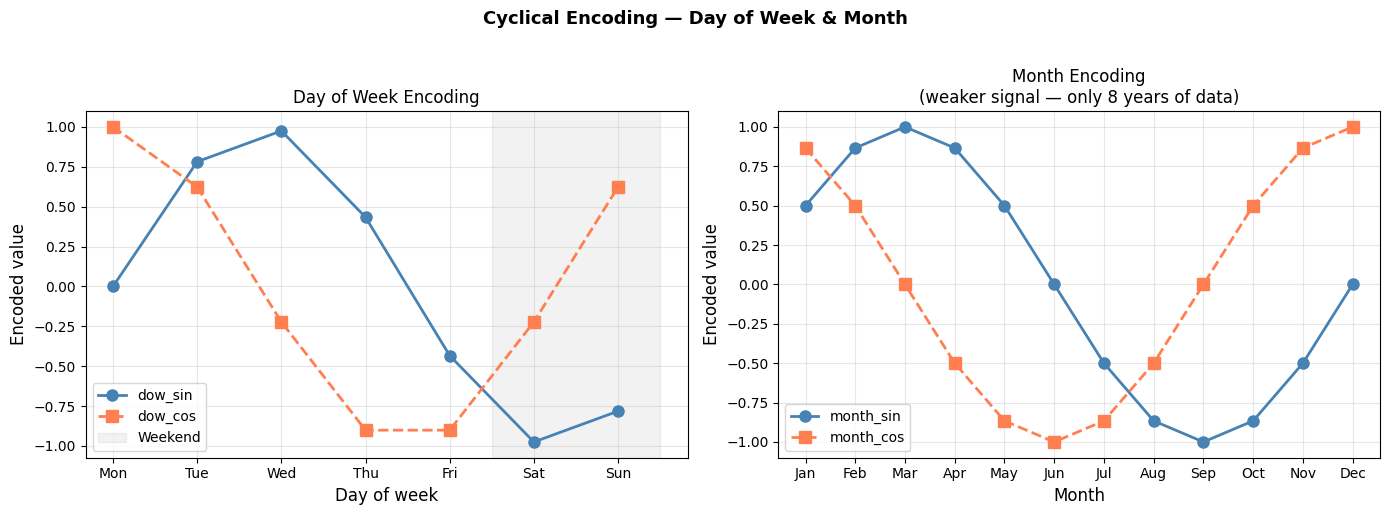

In [6]:
# ── Plot 2: Day of Week & Month ────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Day of week
days = np.arange(7)
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
d_sin = np.sin(2 * np.pi * days / 7)
d_cos = np.cos(2 * np.pi * days / 7)

ax1 = axes[0]
ax1.plot(days, d_sin, 'o-', color='steelblue', linewidth=2,
         markersize=8, label='dow_sin')
ax1.plot(days, d_cos, 's--', color='coral', linewidth=2,
         markersize=8, label='dow_cos')
ax1.axvspan(4.5, 6.5, alpha=0.1, color='gray', label='Weekend')
ax1.set_xticks(days)
ax1.set_xticklabels(day_labels)
ax1.set_xlabel('Day of week', fontsize=12)
ax1.set_ylabel('Encoded value', fontsize=12)
ax1.set_title('Day of Week Encoding', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Month
months = np.arange(1, 13)
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
m_sin = np.sin(2 * np.pi * months / 12)
m_cos = np.cos(2 * np.pi * months / 12)

ax2 = axes[1]
ax2.plot(months, m_sin, 'o-', color='steelblue', linewidth=2,
         markersize=8, label='month_sin')
ax2.plot(months, m_cos, 's--', color='coral', linewidth=2,
         markersize=8, label='month_cos')
ax2.set_xticks(months)
ax2.set_xticklabels(month_labels)
ax2.set_xlabel('Month', fontsize=12)
ax2.set_ylabel('Encoded value', fontsize=12)
ax2.set_title('Month Encoding\n(weaker signal — only 8 years of data)', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle('Cyclical Encoding — Day of Week & Month',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cyclical_dow_month_encoding.png', dpi=150, bbox_inches='tight')
plt.show()